In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset



device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")



In [74]:
#Import files


data_dir = Path("data")
episodes = []

for fp in sorted(data_dir.glob("data*.npz")):
    z = np.load(fp)
    episodes.append(z["data"]) 

len(episodes), episodes[1].shape


(26, (102, 13))

In [75]:
#Look at file data.
episode_data = episodes[2]

episode_data[100:150, 12:14]




array([[0.02885356],
       [0.03377135]])

In [93]:
#Structure input files for LSTM
from copy import deepcopy
lookback = 5

def parse_data(data, lookback): #TODO: Add padding so that first few values can be added to train
    data = deepcopy(data)
    X= []
    Y = []    #NN outputs force and torque, each Y_i should be accompanied with states from X_i-5 to X_i
    

    # print (data[1].shape)
    for i in range(len(data)): #go across all episodes  
        episode_data = data[i]
        episode_length = episode_data.shape[0]
        Y_new = episode_data[lookback:, 12:14] #Get all force and torque vectors. Ignore first 5 elements since no history
        Y.append(Y_new)


        #Need shape (ep_length, lookback, data)
        episode_data_x = episode_data[:, 1:12] #shape 2000, 11
        for j in range(episode_length - lookback):   #TODO def not the most efficient way to parse all the data
            row_xs = []
            for k in range(lookback):
                hist_timestamp = j + k
                x_hist = episode_data_x[hist_timestamp,:]
                row_xs.append(x_hist)
                #add X hist
            X.append(row_xs)

    #Combine data cross all episodes into one
    X= np.array(X)
    print(Y[0].shape)
    Y = np.concatenate(Y, axis=0)


    return X, Y



X, Y = parse_data(episodes, lookback)
print("X Shape",X.shape)
print("Y Shape", Y.shape)

Y[1000:1100, :]


#

(297, 1)
X Shape (5822, 5, 11)
Y Shape (5822, 1)


array([[ 0.6069937 ],
       [ 0.62933207],
       [ 0.63701234],
       [ 0.62821492],
       [ 0.60173819],
       [ 0.55720425],
       [ 0.49498481],
       [ 0.4164068 ],
       [ 0.3236051 ],
       [ 0.21955269],
       [ 0.10780276],
       [-0.0077611 ],
       [-0.12326894],
       [-0.23512254],
       [-0.34025123],
       [-0.43627217],
       [-0.52146432],
       [-0.59483071],
       [-0.65591569],
       [-0.70471535],
       [-0.74160176],
       [-0.76706326],
       [-0.78177217],
       [-0.78640626],
       [-0.7816364 ],
       [-0.76815251],
       [-0.74661332],
       [-0.71772664],
       [-0.68220411],
       [-0.64084762],
       [-0.59448437],
       [-0.54398707],
       [-0.49027348],
       [-0.43424077],
       [-0.37675798],
       [-0.31862569],
       [-0.26053401],
       [-0.20298619],
       [-0.14630039],
       [-0.09048003],
       [-0.03517872],
       [ 0.02047288],
       [ 0.07789229],
       [ 0.13915988],
       [ 0.20671118],
       [ 0

In [77]:
#Post process data
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler(feature_range=(-1, 1))
# X = scaler.fit_transform(X)
# Y = scaler.fit_transform(Y)

split_index = int(len(X) * 0.95)
X_train = X[:split_index]
X_test = X[split_index:]

Y_train = Y[:split_index]
Y_test = Y[split_index:]

X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()


X_train.shape, X_test.shape, Y_train.shape, Y_test.shape


(torch.Size([5530, 5, 11]),
 torch.Size([292, 5, 11]),
 torch.Size([5530, 1]),
 torch.Size([292, 1]))

In [78]:
class TrajectoryDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.Y[i]

train_dataset = TrajectoryDataset(X_train, Y_train)
test_dataset = TrajectoryDataset(X_test, Y_test)

from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
for _, batch in enumerate(train_loader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)
    break

torch.Size([16, 5, 11]) torch.Size([16, 1])


In [95]:
class FeedForward(nn.Module):
    def __init__(self, input_size, hidden_size1,hidden_size2, output_size ):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size1 )
        self.layer2 = nn.Linear(hidden_size1, hidden_size2 )
        self.layer3 = nn.Linear(hidden_size2, output_size )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        out = self.layer3(x)
        return out



class LSTM(nn.Module):

    # input size = number features = 11
    #hidden size can be anything, use 20 for now
    #num_stacked_layers, idk what it does
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layers,
                            batch_first=True)

        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# model = LSTM(11, 20, 1)
model = FeedForward(11, 80, 70, 2)

model.to(device)
model

FeedForward(
  (layer1): Linear(in_features=11, out_features=80, bias=True)
  (layer2): Linear(in_features=80, out_features=70, bias=True)
  (layer3): Linear(in_features=70, out_features=2, bias=True)
)

In [96]:
loss_function = nn.MSELoss()
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
num_epochs = 10

def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        output = model(x_batch)
        # print("output", output)
        # print(output.shape, y_batch.shape)
        # print(
        #     output[1, :].detach().cpu().numpy(),
        #     y_batch[1, :].detach().cpu().numpy()
        # )        
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_index % 100 == 99:  # print every 100 batches
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index+1,
                                                    avg_loss_across_batches))
            running_loss = 0.0
    print()

def validate_one_epoch():
    model.train(False)
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(test_loader)

    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()

In [97]:


for epoch in range(num_epochs):
    train_one_epoch()
    validate_one_epoch()

Epoch: 1


/Users/jiaanli/miniforge3/envs/cbf/lib/python3.13/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16, 5, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (5) must match the size of tensor b (16) at non-singleton dimension 1

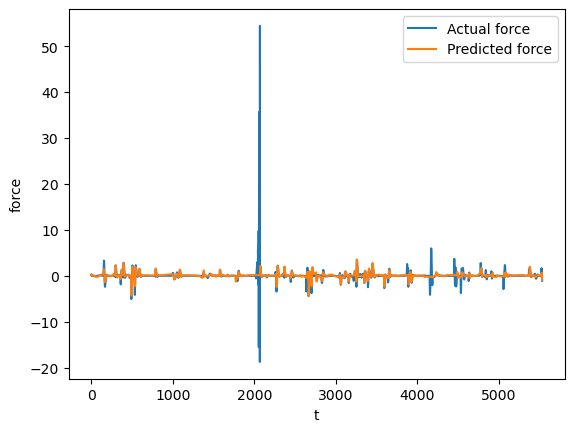

In [90]:
with torch.no_grad():
    predicted = model(X_train.to(device)).to('cpu').numpy()


plt.plot(Y_train, label='Actual force')
plt.plot(predicted[:,0], label='Predicted force')
plt.xlabel('t')
plt.ylabel('force')
plt.legend()
plt.show()


In [89]:
predicted.shape, Y_train.shape

((5530, 2), torch.Size([5530, 1]))